**Assignment 5 — Classification: Binary & Multiclass**

Logistic Regression and Support Vector Machine (SVM).

In [7]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [8]:
data = fetch_openml(name='adult', version=2, as_frame=True)
df = data.frame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [13]:
for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
        df[col] = df[col].astype(str)
        df[col] = LabelEncoder().fit_transform(df[col])



In [14]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8163578667212611
Precision: 0.6030756442227764
Recall: 0.6336244541484716
ROC-AUC: 0.7529667931927008


In [17]:
cv_scores = cross_val_score(model, X, y, cv=5)
print(cv_scores)
print(cv_scores.mean())

[0.8130822  0.81246801 0.81900082 0.81152744 0.81951269]
0.8151182319776854


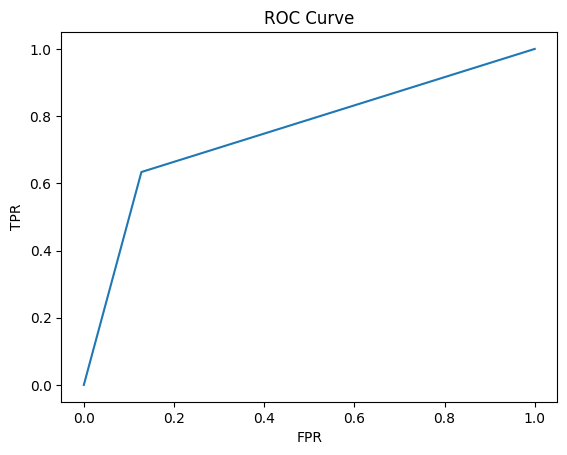

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

**Conclusion:** A decision tree classifier was trained on the Adult dataset. Performance was evaluated using accuracy, precision, recall, ROC-AUC, and cross-validation.